# Local energy minimization and magnetization textures
A ferromagnetic exchange wants neighboring spins parallel, while a Dzyaloshinskii-Moriya
interaction $\vec D_{ij}\cdot(\vec S_i\times\vec S_j)$ wants them to rotate with respect to
each other, and the competition between the two gives rise to magnetization textures: spin
spirals and, once a magnetic field is added, skyrmions. `sm.minimize_energy()` is a local,
gradient-based minimization of the classical energy, so what it returns is the local minimum
closest to where it started: `theta0` and `phi0` set that starting point, and
`classicalspin.generating_profiles()` builds a skyrmion or a spiral to start from, while by
default it starts from random angles. `sm.get_magnetization()` gives the three components of
the spin at every site, the real-space map of the texture, and `sm.get_local_energy()` gives
the energy of every site, which tells where in the texture the cost of the rotation sits.
Here we use a finite square flake, with open boundaries, and an interfacial
Dzyaloshinskii-Moriya coupling with $\vec D_{ij}\propto\hat z\times\hat r_{ij}$, which favors
Neel-type textures, whose spins rotate in the plane containing the direction of propagation.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import classicalspin
np.random.seed(1) # reproducible random starting points

### A skyrmion in a magnetic field
We start from a skyrmion profile, the spin pointing down at the center and up at the border,
and let the minimization relax it in a field that favors spins pointing up. The left map is
$m_z$ with the in-plane components drawn as arrows, which point radially, the signature of a
Neel skyrmion. The right map is the local energy measured from the one of the same flake
relaxed without the skyrmion, in which the spins at the edges tilt as well, so that the map
shows only what the skyrmion changes, and not the missing bonds of the edge sites. The skyrmion
costs energy in a ring around its core, where the spins turn through the plane, and gains
energy in its outer tail, where they tilt gently away from the field. The two nearly cancel,
and the total printed below is small compared with the energy of a single bond, meaning that
the skyrmion is a metastable texture, a local minimum close in energy to the state without it.

Minimum energy -648.9037
Minimum energy per spin -4.5062757


Minimum energy -649.4227
Minimum energy per spin -4.50988


Energy of the skyrmion: 0.5190401


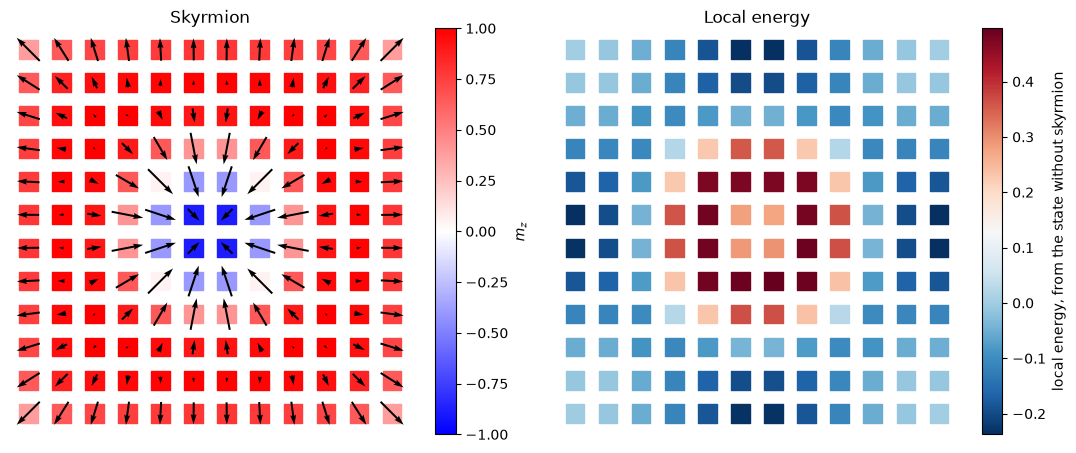

In [2]:
L = 12
g = geometry.square_lattice().get_supercell(L) # square flake
g.dimensionality = 0 # open boundaries
g.center() # origin at the center of the flake

def build_model(b):
    sm = classicalspin.SpinModel(g)
    sm.add_heisenberg(Jij=[-1.0]) # ferromagnetic first-neighbor exchange
    fdm = classicalspin.generating_functions(name="DM",J=0.8,v=np.array([0.,0.,1.]))
    sm.add_tensor(fdm) # interfacial Dzyaloshinskii-Moriya interaction
    sm.add_field([0.,0.,-b]) # Zeeman field favoring spins along +z
    return sm

sm = build_model(0.6)
th,ph = classicalspin.generating_profiles(g.r,name="skyrmion") # skyrmion profile
sm.minimize_energy(theta0=np.pi-th,phi0=ph,tries=1) # relax it, core pointing down
mx,my,mz = sm.get_magnetization()
el = sm.get_local_energy() # energy of every site

smf = build_model(0.6) # the same flake without the skyrmion
n = len(g.r)
smf.minimize_energy(theta0=0.1*np.random.random(n),phi0=2*np.pi*np.random.random(n),tries=1)
el0 = smf.get_local_energy()
print("Energy of the skyrmion:",np.sum(el-el0))

fig,axs = plt.subplots(1,2,figsize=(11,4.5))
sc = axs[0].scatter(g.x,g.y,c=mz,cmap="bwr",vmin=-1,vmax=1,s=180,marker="s")
axs[0].quiver(g.x,g.y,mx,my,pivot="middle")
plt.colorbar(sc,ax=axs[0],label="$m_z$")
axs[0].set_title("Skyrmion")
sc = axs[1].scatter(g.x,g.y,c=el-el0,cmap="RdBu_r",s=180,marker="s")
plt.colorbar(sc,ax=axs[1],label="local energy, from the state without skyrmion")
axs[1].set_title("Local energy")
for ax in axs: ax.set_aspect("equal") ; ax.axis("off")
plt.tight_layout()
plt.show()

### A labyrinth of spiral domains without field
Without a field the uniform state is no longer the one to compare with: the
Dzyaloshinskii-Moriya coupling favors a spin spiral, the magnetization rotating along one
direction with a period of roughly $2\pi J/D$ lattice constants. Starting from random angles,
the minimization does not find a single spiral across the flake but a labyrinth, stripes of up
and down magnetization joined by walls in which the spins rotate, each stripe a piece of the
spiral with the right period and a different direction. This is what a local minimization
means in practice: the result is the local minimum closest to the random start, and a
different start gives a different labyrinth, while `tries` keeps the lowest energy of several
starts.

Minimum energy -1114.366
Minimum energy per spin -4.352992


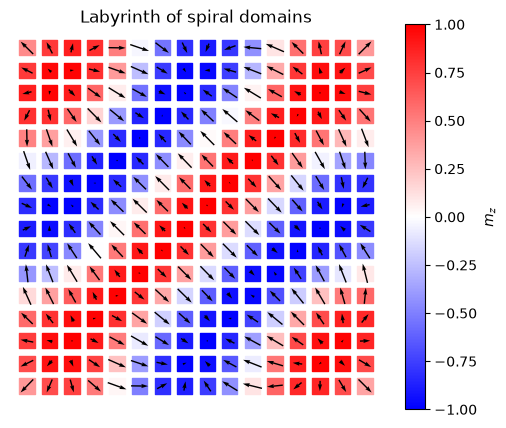

In [3]:
L = 16
g = geometry.square_lattice().get_supercell(L)
g.dimensionality = 0
g.center()
sm = build_model(0.0)
sm.minimize_energy(tries=1) # start from random angles
mx,my,mz = sm.get_magnetization()

plt.figure(figsize=(6,5))
sc = plt.scatter(g.x,g.y,c=mz,cmap="bwr",vmin=-1,vmax=1,s=120,marker="s")
plt.quiver(g.x,g.y,mx,my,pivot="middle")
plt.colorbar(sc,label="$m_z$")
plt.gca().set_aspect("equal") ; plt.axis("off")
plt.title("Labyrinth of spiral domains")
plt.show()